In [6]:
import sys
from pathlib import Path
sys.path.append('../')

from matching_clustering.utils import LapOT, lot_quad
from matching_clustering.precompute_helpers import graph_laplacians, cost_matrix_c
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances


### Example: 1D Gaussian Mixture
#### The data:

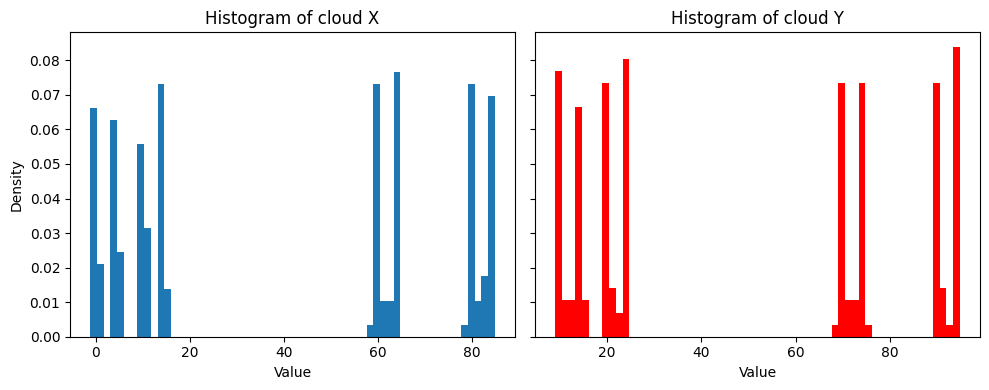

In [14]:
rng = np.random.default_rng(0)

n_groups = 4
samples_per_group = 25

# Gaussian parameters for X
means_X = np.array([0.0, 4.0, 10.0, 14.0, 60.0, 64.0, 80.0, 84.0 ])
stds_X  = np.array([0.5 for i in range(8)])

# Gaussian parameters for Y (different)
means_Y = np.array([10.0, 14.0, 20.0, 24.0, 70.0, 74.0, 90.0, 94.0])
stds_Y  = np.array([0.5 for i in range(8)])

# Generate point clouds
X = np.vstack([
    rng.normal(mu, sigma, size=(samples_per_group, 1))
    for mu, sigma in zip(means_X, stds_X)
])

Y = np.vstack([
    rng.normal(mu, sigma, size=(samples_per_group, 1))
    for mu, sigma in zip(means_Y, stds_Y)
])


# ---- Plot histograms side by side and save figure ----

# Path to save the figure
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "LapLOT_1D_example_data.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)



fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(X.flatten(), bins=60, density=True)
axes[0].set_title("Histogram of cloud X")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

axes[1].hist(Y.flatten(), bins=60, density=True, color='red')
axes[1].set_title("Histogram of cloud Y")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight")
plt.show()


#### Pre-compute the matrices $L_X, L_Y, C$

In [7]:
### Pre-compute graph Laplacians and cost matrix

pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')

L_X, L_Y, W_X, W_Y, a_, b_ = graph_laplacians(X, Y, sigma_x=0.5, sigma_y=0.5)

_, _, _, _, a, b = graph_laplacians(X, Y, sigma_x=0.077, sigma_y=0.077) # adjust sigma values for smaller significatnce neighborhoodd

C = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 1048 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 40000 out of 40000 | elapsed:    3.5s finished


#### Solve $\text{LapOT}$ as reference and $\text{LapLOT}$ for various ranks $r$ and visually compare the results
#### NOTE: 
The current initialization of LapLOT is random, and since the optimization problem is not convex, the optimal solution could vary. 


Implement fixed point algorithm
max of entropy term :-0.8869738424116864 
 max of main term: 1.614656937943127
max of entropy term :-0.8903915404817866 
 max of main term: 1.6178149592851356
max of entropy term :-0.8899061390655091 
 max of main term: 1.6173145834242326
max of entropy term :-0.8900251752699493 
 max of main term: 1.6174317762841486
max of entropy term :-0.8899906707152369 
 max of main term: 1.617396902777821
max of entropy term :-0.8900028277674621 
 max of main term: 1.6174089754868215
max of entropy term :-0.8899980451694651 
 max of main term: 1.617404160802553
max of entropy term :-0.8900001677267882 
 max of main term: 1.6174062778695715
max of entropy term :-0.8899991579804809 
 max of main term: 1.6174052631091738
max of entropy term :-0.8899996724071088 
 max of main term: 1.6174057776472943
Terminated after 9 iterations (objective increased)
Iteration 0, error: 7.171828709997455e-10
Objective 6.190702186571093


/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Iteration 10, error: 5.082473631008533e-10
Objective 6.187363676155456
Iteration 20, error: 5.076182505872066e-10
Objective 6.1841642441487
Iteration 30, error: 5.041963142672982e-10
Objective 6.180135877697738
Iteration 40, error: 4.978180367234921e-10
Objective 6.174058207588275
Iteration 50, error: 4.882160007208107e-10
Objective 6.1640980768493705
Iteration 60, error: 4.750727772154415e-10
Objective 6.147378406408042
Iteration 70, error: 4.581322878854554e-10
Objective 6.1195220821737735
Iteration 80, error: 4.373596277939169e-10
Objective 6.074373159434733
Iteration 90, error: 4.129967910369452e-10
Objective 6.0043293452841695
Iteration 100, error: 3.860120315037174e-10
Objective 5.901803613834094
Iteration 110, error: 3.577666813159207e-10
Objective 5.7619327657508075
Iteration 120, error: 9.896448342972958e-10
Objective 5.5856653591159535
Iteration 130, error: 9.117119523185124e-10
Objective 5.381317194793661
Iteration 140, error: 8.467212759900695e-10
Objective 5.16311127105967

/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/.venv/lib/python3.12/site-packages/ot/lowrank.py:310: UserWarning: Dykstra did not converge. You might want to increase the number of iterations `numItermax` 
  warnings.warn(


Iteration 400, error: 1.4832406425739146e-09
Objective 2.1927411937013246
Iteration 410, error: 6.054317996061897e-09
Objective 2.174888248236631
Iteration 420, error: 1.547025221833673e-08
Objective 2.159819428941259
Iteration 430, error: 2.939271805005438e-08
Objective 2.1472139161250716
Iteration 440, error: 4.561848880485436e-08
Objective 2.1367346006295564
Iteration 450, error: 6.164348351067448e-08
Objective 2.1280514210103343
Iteration 460, error: 7.584473833990369e-08
Objective 2.1208563481258818
Iteration 470, error: 8.754810713005979e-08
Objective 2.114872800982285
Iteration 480, error: 9.669814641224494e-08
Objective 2.1098661243926737
Iteration 490, error: 1.0382031228544785e-07
Objective 2.1056248164072615
Iteration 500, error: 1.0931623758489933e-07
Objective 2.1019699340545293
Iteration 510, error: 1.1354508655056163e-07
Objective 2.0987564453690783
Iteration 520, error: 1.1686838755377597e-07
Objective 2.095865365296282
Iteration 530, error: 1.1950421755547217e-07
Objec

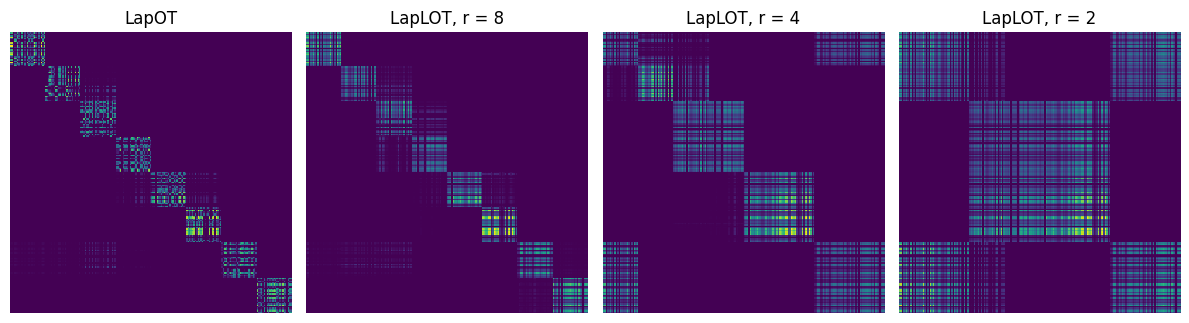

In [13]:
prob = LapOT(L_X, L_Y, C, l=0.1, l_x=1, l_y=1, w=a, v=b)
pi_fp = prob.solve(method='fp', verbose=False)

pi_low_rank_2 = lot_quad(C, L_X, L_Y, a, b, r=2, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)
pi_low_rank_4 = lot_quad(C, L_X, L_Y, a, b, r=4, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)
pi_low_rank_8 = lot_quad(C, L_X, L_Y, a, b, r=8, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)

# Save path for the figure
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "LapLOT_1D_example_results.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Plot the matrices side by side
matrices = [pi_fp, pi_low_rank_8 ,pi_low_rank_4, pi_low_rank_2]
titles = ['LapOT', 'LapLOT, r = 8', 'LapLOT, r = 4','LapLOT, r = 2' ]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    ax.axis('off')  # optional: hide axis ticks
plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight")    